In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Momentum Strategy Backtest

This project builds a simple rule-based equity momentum strategy using historical stock price data.

The goal is to test whether stocks with stronger recent momentum can outperform a passive benchmark when selected and rebalanced monthly.

The strategy uses:
- A selected universe of large-cap U.S. stocks
- 60-day momentum as the main signal
- Monthly portfolio rebalancing
- Equal-weighted portfolio construction
- SPY as the benchmark
- Performance metrics such as cumulative return, Sharpe ratio, volatility, and maximum drawdown
  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [4]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "JPM", "JNJ", "XOM",
    "PG", "KO", "PEP", "WMT", "UNH"
]

benchmark = "SPY"

start_date = "2015-01-01"
end_date = "2024-12-31"

In [5]:
all_tickers = tickers + [benchmark]

price_data = yf.download(
    all_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

price_data.head()

Price           Close                                                                                                                                                                          High                                                                                                                                                                           Low                                                                                                                                                                          Open                                                                                                                                                                        Volume                                                                                                                                                    
Ticker           AAPL     AMZN      GOOGL        JNJ        JPM         KO       META       MSFT      NVDA        PEP         PG         SPY       TSLA        UNH        WMT        XOM       AAPL     AMZN      GOOGL        JNJ        JPM         KO       META       MSFT      NVDA        PEP         PG         SPY       TSLA        UNH        WMT        XOM       AAPL     AMZN      GOOGL        JNJ        JPM         KO       META       MSFT      NVDA        PEP         PG         SPY       TSLA        UNH        WMT        XOM       AAPL     AMZN      GOOGL        JNJ        JPM         KO       META       MSFT      NVDA        PEP         PG         SPY       TSLA        UNH        WMT        XOM       AAPL      AMZN     GOOGL      JNJ       JPM        KO      META      MSFT       NVDA      PEP       PG        SPY      TSLA      UNH       WMT       XOM
Date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
2015-01-02  24.192606  15.4260  26.260458  76.548622  46.274315  29.580021  77.839157  39.767681  0.482985  67.283463  65.555756  170.125031  14.620667  83.828789  23.127548  57.533424  24.659508  15.7375  26.570396  77.302981  46.622351  29.762528  78.315423  40.328987  0.486584  67.924660  65.961672  171.325845  14.883333  85.359304  23.348324  57.669775  23.754470  15.3480  26.177641  76.262993  45.963300  29.341359  77.094997  39.580581  0.475307  67.005609  65.178829  169.089854  14.217333  83.188306  23.033315  56.901254  24.648443  15.6290  26.411706  76.936790  46.044757  29.664254  77.968150  39.682636  0.482985  67.632560  65.845693  170.911775  14.858000  84.427686  23.227166  57.173956  212818400  55664000  26480000  5753600  12600000   9921100  18177500  27913900  113680000  3545700  7251400  121465900  71466000  3060900  13505400  10220400
2015-01-05  23.511059  15.1095  25.760094  76.013969  44.837719  29.580021  76.588982  39.401997  0.474828  66.777634  65.244049  167.052597  14.006000  82.447983  23.060230  55.959206  24.042132  15.4190  26.183098  76.702411  46.118796  30.162638  78.632940  39.742180  0.484425  67.718063  65.961652  169.247166  14.433333  83.554271  23.240620  57.266925  23.325184  15.0425  25.675296  75.933407  44.600757  29.537906  76.261549  39.333958  0.472668  66.770508  65.128070  166.746189  13.810667  82.140215  23.022537  55.469585  23

In [6]:
price_data.columns

MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',   'JNJ'),
            ( 'Close',   'JPM'),
            ( 'Close',    'KO'),
            ( 'Close',  'META'),
            ( 'Close',  'MSFT'),
            ( 'Close',  'NVDA'),
            ( 'Close',   'PEP'),
            ( 'Close',    'PG'),
            ( 'Close',   'SPY'),
            ( 'Close',  'TSLA'),
            ( 'Close',   'UNH'),
            ( 'Close',   'WMT'),
            ( 'Close',   'XOM'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',   'JNJ'),
            (  'High',   'JPM'),
            (  'High',    'KO'),
            (  'High',  'META'),
            (  'High',  'MSFT'),
            (  'High',  'NVDA'),
            (  'High',   'PEP'),
            (  'High',    'PG'),
            (  'High',   'SPY'),
            (  'High',  'TSLA'),
            (  'High',   'UNH'),
          

In [7]:
prices = price_data["Close"].copy()

prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,SPY,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,
2015-01-02,24.192606,15.4260,26.260458,76.548622,46.274315,29.580021,77.839157,39.767681,0.482985,67.283463,65.555756,170.125031,14.620667,83.828789,23.127548,57.533424
2015-01-05,23.511059,15.1095,25.760094,76.013969,44.837719,29.580021,76.588982,39.401997,0.474828,66.777634,65.244049,167.052597,14.006000,82.447983,23.060230,55.959206
2015-01-06,23.513275,14.7645,25.124352,75.640480,43.675137,29.804630,75.557068,38.823681,0.460432,66.271774,64.946877,165.479202,14.085333,82.281624,23.237934,55.661716
2015-01-07,23.842979,14.9210,25.050457,77.310310,43.741776,30.176670,75.557068,39.316933,0.459232,68.209641,65.287544,167.541214,14.063333,83.121742,23.854485,56.225704
2015-01-08,24.759094,15.0230,25.137741,77.918159,44.719250,30.541677,77.571259,40.473568,0.476507,69.449318,66.034149,170.514252,14.041333,87.089417,24.357958,57.161552


In [8]:
prices.isna().sum()

Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
NVDA     0
PEP      0
PG       0
SPY      0
TSLA     0
UNH      0
WMT      0
XOM      0
dtype: int64

In [9]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,SPY,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.020517,-0.019054,-0.006984,-0.031045,0.000000,-0.016061,-0.009196,-0.016890,-0.007518,-0.004755,-0.018060,-0.042041,-0.016472,-0.002911,-0.027362
2015-01-06,0.000094,-0.022833,-0.024679,-0.004913,-0.025929,0.007593,-0.013473,-0.014677,-0.030318,-0.007575,-0.004555,-0.009419,0.005664,-0.002018,0.007706,-0.005316
2015-01-07,0.014022,0.010600,-0.002941,0.022076,0.001526,0.012483,0.000000,0.012705,-0.002606,0.029241,0.005245,0.012461,-0.001562,0.010210,0.026532,0.010132
2015-01-08,0.038423,0.006836,0.003484,0.007862,0.022346,0.012096,0.026658,0.029418,0.037618,0.018175,0.011436,0.017745,-0.001564,0.047733,0.021106,0.016644
2015-01-09,0.001072,-0.011749,-0.012211,-0.013629,-0.017387,-0.011032,-0.005628,-0.008405,0.004028,-0.006771,-0.009330,-0.008014,-0.018802,-0.009360,-0.012380,-0.001409


In [10]:
print("Price data shape:", prices.shape)
print("Returns data shape:", returns.shape)

print("Start date:", prices.index.min())
print("End date:", prices.index.max())

prices.tail()

Price data shape: (2515, 16)
Returns data shape: (2514, 16)
Start date: 2015-01-02 00:00:00
End date: 2024-12-30 00:00:00


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,SPY,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,
2024-12-23,253.649414,225.059998,193.734344,140.209885,231.216553,60.178539,597.452820,431.078857,139.624252,144.188354,161.412720,586.186584,430.600006,490.358032,89.139961,101.857849
2024-12-24,256.560822,229.050003,195.207520,140.769684,235.018600,60.622307,605.321350,435.119690,140.174072,145.637009,162.209671,592.702087,462.279999,490.125610,91.438751,101.953667
2024-12-26,257.375549,227.050003,194.699875,140.509079,235.823608,60.361835,600.938904,433.911407,139.884155,145.284378,163.381073,592.741577,454.130005,495.016205,91.547279,102.039902
2024-12-27,253.967377,223.750000,191.872925,139.997543,233.912903,60.246071,597.413025,426.404083,136.965118,145.713257,162.776154,586.502075,431.660004,493.892822,90.432411,102.030319
2024-12-30,250.598907,221.300003,190.359955,138.347107,232.118576,59.840889,588.877258,420.758698,137.444946,144.598175,160.433365,579.809143,417.410004,491.771973,89.357018,101.340408


In [11]:
momentum_20d = prices.pct_change(20)
momentum_60d = prices.pct_change(60)

momentum_20d.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,SPY,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
momentum_60d.tail()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,PEP,PG,SPY,TSLA,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,
2024-12-23,0.121870,0.197319,0.188491,-0.092716,0.139434,-0.124486,0.058118,0.018927,0.150574,-0.102481,-0.025650,0.044134,0.653229,-0.126438,0.134999,-0.074655
2024-12-24,0.109374,0.229271,0.183809,-0.092803,0.156193,-0.118889,0.062540,0.023029,0.154724,-0.093730,-0.018861,0.051526,0.766923,-0.131078,0.150283,-0.084846
2024-12-26,0.146302,0.226435,0.172670,-0.094092,0.181559,-0.120840,0.047473,0.043493,0.196065,-0.102941,-0.010862,0.061102,0.760057,-0.120332,0.144279,-0.104769
2024-12-27,0.128279,0.211031,0.163517,-0.092797,0.170572,-0.113876,0.047981,0.034190,0.152877,-0.090582,-0.008104,0.049490,0.733435,-0.135679,0.142149,-0.116565
2024-12-30,0.118791,0.216201,0.154342,-0.099750,0.173252,-0.113720,0.015352,0.021944,0.119247,-0.092079,-0.012036,0.039413,0.734439,-0.140029,0.128567,-0.130127


In [13]:
stock_tickers = [ticker for ticker in tickers if ticker != benchmark]

stock_prices = prices[stock_tickers]
stock_returns = returns[stock_tickers]

benchmark_prices = prices[benchmark]
benchmark_returns = returns[benchmark]

print("Stock prices shape:", stock_prices.shape)
print("Stock returns shape:", stock_returns.shape)
print("Benchmark returns shape:", benchmark_returns.shape)

Stock prices shape: (2515, 15)
Stock returns shape: (2514, 15)
Benchmark returns shape: (2514,)


In [14]:
monthly_rebalance_dates = stock_prices.resample("ME").last().index

monthly_rebalance_dates[:5], monthly_rebalance_dates[-5:]

(DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31'], dtype='datetime64[ns]', name='Date', freq='ME'),
 DatetimeIndex(['2024-08-31', '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31'], dtype='datetime64[ns]', name='Date', freq='ME'))

In [15]:
top_n = 5

monthly_momentum = momentum_60d[stock_tickers].reindex(monthly_rebalance_dates)

selected_stocks = {}

for date in monthly_momentum.index:
    signal = monthly_momentum.loc[date].dropna()
    
    if len(signal) >= top_n:
        selected_stocks[date] = signal.sort_values(ascending=False).head(top_n).index.tolist()

selected_stocks

{Timestamp('2015-03-31 00:00:00'): ['AMZN', 'UNH', 'AAPL', 'META', 'GOOGL'],
 Timestamp('2015-04-30 00:00:00'): ['MSFT', 'AMZN', 'JPM', 'NVDA', 'AAPL'],
 Timestamp('2015-06-30 00:00:00'): ['TSLA', 'AMZN', 'JPM', 'MSFT', 'UNH'],
 Timestamp('2015-07-31 00:00:00'): ['AMZN', 'GOOGL', 'META', 'TSLA', 'JPM'],
 Timestamp('2015-08-31 00:00:00'): ['AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA'],
 Timestamp('2015-09-30 00:00:00'): ['NVDA', 'AMZN', 'GOOGL', 'META', 'MSFT'],
 Timestamp('2015-11-30 00:00:00'): ['NVDA', 'AMZN', 'MSFT', 'GOOGL', 'META'],
 Timestamp('2015-12-31 00:00:00'): ['NVDA', 'AMZN', 'MSFT', 'GOOGL', 'META'],
 Timestamp('2016-02-29 00:00:00'): ['WMT', 'PG', 'JNJ', 'UNH', 'KO'],
 Timestamp('2016-03-31 00:00:00'): ['WMT', 'META', 'UNH', 'NVDA', 'KO'],
 Timestamp('2016-05-31 00:00:00'): ['NVDA', 'AMZN', 'TSLA', 'UNH', 'META'],
 Timestamp('2016-06-30 00:00:00'): ['NVDA', 'AMZN', 'XOM', 'JNJ', 'UNH'],
 Timestamp('2016-08-31 00:00:00'): ['NVDA', 'MSFT', 'GOOGL', 'AAPL', 'META'],
 Timestamp('

In [16]:
selected_df = pd.DataFrame.from_dict(
    selected_stocks,
    orient="index"
)

selected_df.columns = [f"Stock_{i+1}" for i in range(selected_df.shape[1])]

selected_df.head(10)

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
2015-03-31,AMZN,UNH,AAPL,META,GOOGL
2015-04-30,MSFT,AMZN,JPM,NVDA,AAPL
2015-06-30,TSLA,AMZN,JPM,MSFT,UNH
2015-07-31,AMZN,GOOGL,META,TSLA,JPM
2015-08-31,AMZN,GOOGL,META,NVDA,TSLA
2015-09-30,NVDA,AMZN,GOOGL,META,MSFT
2015-11-30,NVDA,AMZN,MSFT,GOOGL,META
2015-12-31,NVDA,AMZN,MSFT,GOOGL,META
2016-02-29,WMT,PG,JNJ,UNH,KO
2016-03-31,WMT,META,UNH,NVDA,KO


In [18]:
portfolio_returns = pd.Series(index=stock_returns.index, dtype=float)

rebalance_dates = list(selected_stocks.keys())

for i in range(len(rebalance_dates) - 1):
    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i + 1]
    
    selected = selected_stocks[current_date]
    
    period_returns = stock_returns.loc[
        (stock_returns.index > current_date) & 
        (stock_returns.index <= next_date),
        selected
    ]
    
    portfolio_returns.loc[period_returns.index] = period_returns.mean(axis=1)

portfolio_returns = portfolio_returns.dropna()

portfolio_returns.head()

Date
2015-04-01   -0.005915
2015-04-02   -0.000603
2015-04-06    0.009526
2015-04-07   -0.004051
2015-04-08    0.005772
dtype: float64

In [19]:
aligned_benchmark_returns = benchmark_returns.loc[portfolio_returns.index]

print("Portfolio returns shape:", portfolio_returns.shape)
print("Benchmark returns shape:", aligned_benchmark_returns.shape)

portfolio_returns.head(), aligned_benchmark_returns.head()

Portfolio returns shape: (2414,)
Benchmark returns shape: (2414,)


(Date
 2015-04-01   -0.005915
 2015-04-02   -0.000603
 2015-04-06    0.009526
 2015-04-07   -0.004051
 2015-04-08    0.005772
 dtype: float64,
 Date
 2015-04-01   -0.003536
 2015-04-02    0.003598
 2015-04-06    0.006733
 2015-04-07   -0.002646
 2015-04-08    0.003377
 Name: SPY, dtype: float64)

In [20]:
cumulative_strategy = (1 + portfolio_returns).cumprod()
cumulative_benchmark = (1 + aligned_benchmark_returns).cumprod()

cumulative_returns = pd.DataFrame({
    "Momentum Strategy": cumulative_strategy,
    "SPY Benchmark": cumulative_benchmark
})

cumulative_returns.tail()

,Momentum Strategy,SPY Benchmark
Date,,
2024-10-25,23.592567,3.312708
2024-10-28,23.655880,3.322950
2024-10-29,23.570566,3.328327
2024-10-30,23.589078,3.318259
2024-10-31,23.375676,3.253210


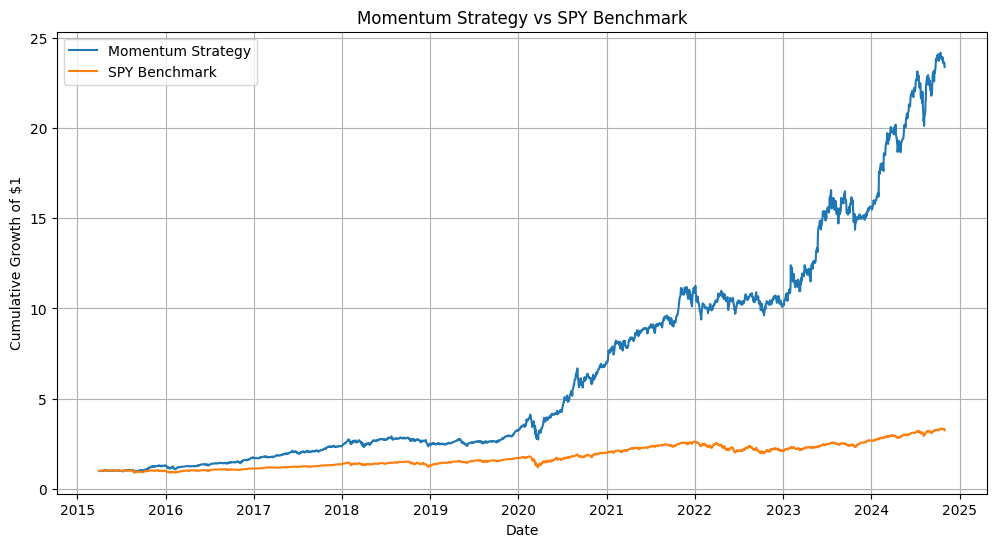

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(cumulative_returns.index, cumulative_returns["Momentum Strategy"], label="Momentum Strategy")
plt.plot(cumulative_returns.index, cumulative_returns["SPY Benchmark"], label="SPY Benchmark")

plt.title("Momentum Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
def calculate_performance_metrics(returns, risk_free_rate=0.0):
    total_return = (1 + returns).prod() - 1
    
    trading_days = 252
    annualized_return = (1 + total_return) ** (trading_days / len(returns)) - 1
    
    annualized_volatility = returns.std() * np.sqrt(trading_days)
    
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative / running_max) - 1
    max_drawdown = drawdown.min()
    
    win_rate = (returns > 0).mean()
    
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate
    }

In [24]:
strategy_metrics = calculate_performance_metrics(portfolio_returns)
benchmark_metrics = calculate_performance_metrics(aligned_benchmark_returns)

metrics_df = pd.DataFrame({
    "Momentum Strategy": strategy_metrics,
    "SPY Benchmark": benchmark_metrics
})

metrics_df

,Momentum Strategy,SPY Benchmark
Total Return,22.375676,2.253210
Annualized Return,0.389590,0.131047
Annualized Volatility,0.240155,0.177646
Sharpe Ratio,1.622244,0.737687
Max Drawdown,-0.335315,-0.337173
Win Rate,0.581193,0.546810


In [25]:
formatted_metrics = metrics_df.copy()

percentage_rows = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Win Rate"
]

for row in percentage_rows:
    formatted_metrics.loc[row] = formatted_metrics.loc[row].apply(lambda x: f"{x:.2%}")

formatted_metrics.loc["Sharpe Ratio"] = formatted_metrics.loc["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

formatted_metrics

/tmp/ipykernel_57/3490717105.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2237.57%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_metrics.loc[row] = formatted_metrics.loc[row].apply(lambda x: f"{x:.2%}")
/tmp/ipykernel_57/3490717105.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '225.32%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_metrics.loc[row] = formatted_metrics.loc[row].apply(lambda x: f"{x:.2%}")


,Momentum Strategy,SPY Benchmark
Total Return,2237.57%,225.32%
Annualized Return,38.96%,13.10%
Annualized Volatility,24.02%,17.76%
Sharpe Ratio,1.62,0.74
Max Drawdown,-33.53%,-33.72%
Win Rate,58.12%,54.68%


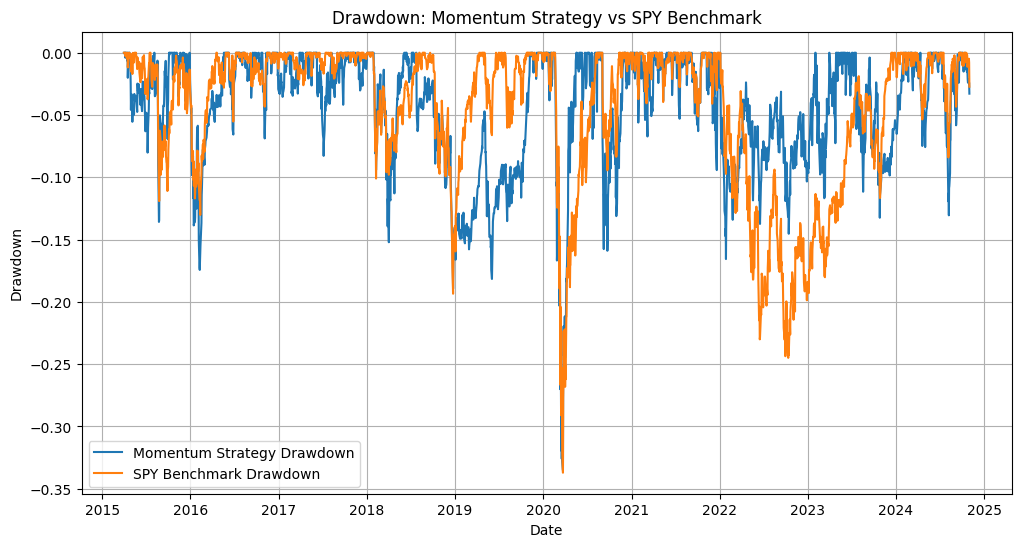

In [26]:
strategy_cumulative = (1 + portfolio_returns).cumprod()
benchmark_cumulative = (1 + aligned_benchmark_returns).cumprod()

strategy_drawdown = (strategy_cumulative / strategy_cumulative.cummax()) - 1
benchmark_drawdown = (benchmark_cumulative / benchmark_cumulative.cummax()) - 1

plt.figure(figsize=(12, 6))

plt.plot(strategy_drawdown.index, strategy_drawdown, label="Momentum Strategy Drawdown")
plt.plot(benchmark_drawdown.index, benchmark_drawdown, label="SPY Benchmark Drawdown")

plt.title("Drawdown: Momentum Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
annual_returns = pd.DataFrame({
    "Momentum Strategy": portfolio_returns,
    "SPY Benchmark": aligned_benchmark_returns
}).resample("YE").apply(lambda x: (1 + x).prod() - 1)

annual_returns

,Momentum Strategy,SPY Benchmark
Date,,
2015-12-31,0.288437,0.003499
2016-12-31,0.321874,0.119979
2017-12-31,0.386525,0.217054
2018-12-31,0.059948,-0.045690
2019-12-31,0.292616,0.312239
2020-12-31,1.176799,0.183316
2021-12-31,0.541898,0.287288
2022-12-31,-0.057578,-0.181754
2023-12-31,0.524687,0.261758


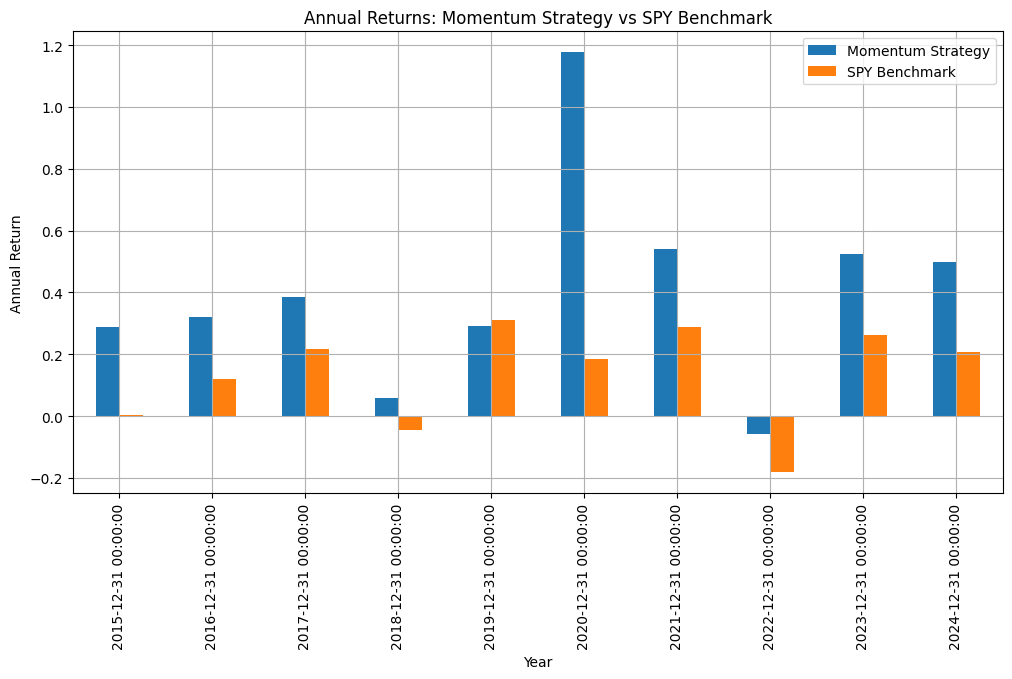

In [28]:
annual_returns.plot(kind="bar", figsize=(12, 6))

plt.title("Annual Returns: Momentum Strategy vs SPY Benchmark")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True)
plt.show()

In [29]:
formatted_metrics

,Momentum Strategy,SPY Benchmark
Total Return,2237.57%,225.32%
Annualized Return,38.96%,13.10%
Annualized Volatility,24.02%,17.76%
Sharpe Ratio,1.62,0.74
Max Drawdown,-33.53%,-33.72%
Win Rate,58.12%,54.68%


In [30]:
annual_returns

,Momentum Strategy,SPY Benchmark
Date,,
2015-12-31,0.288437,0.003499
2016-12-31,0.321874,0.119979
2017-12-31,0.386525,0.217054
2018-12-31,0.059948,-0.045690
2019-12-31,0.292616,0.312239
2020-12-31,1.176799,0.183316
2021-12-31,0.541898,0.287288
2022-12-31,-0.057578,-0.181754
2023-12-31,0.524687,0.261758


The momentum strategy significantly outperformed SPY over the backtest period, delivering higher cumulative return, annualized return, Sharpe ratio, and win rate. However, the strategy also carries important limitations, including survivorship bias, a concentrated large-cap technology exposure, and the lack of transaction cost/slippage modeling in the initial version.

In [32]:
transaction_cost = 0.001  # 0.10%

portfolio_returns_tc = portfolio_returns.copy()

for date in rebalance_dates[1:]:
    future_dates = portfolio_returns_tc.index[portfolio_returns_tc.index >= date]
    
    if len(future_dates) > 0:
        cost_date = future_dates[0]
        portfolio_returns_tc.loc[cost_date] -= transaction_cost

In [35]:
strategy_metrics_tc = calculate_performance_metrics(portfolio_returns_tc)

metrics_with_tc = pd.DataFrame({
    "Momentum Strategy": strategy_metrics,
    "Momentum Strategy with TC": strategy_metrics_tc,
    "SPY Benchmark": benchmark_metrics
})

formatted_metrics_tc = metrics_with_tc.copy().astype(object)

for row in percentage_rows:
    formatted_metrics_tc.loc[row] = formatted_metrics_tc.loc[row].apply(lambda x: f"{x:.2%}")

formatted_metrics_tc.loc["Sharpe Ratio"] = formatted_metrics_tc.loc["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

formatted_metrics_tc

,Momentum Strategy,Momentum Strategy with TC,SPY Benchmark
Total Return,2237.57%,2053.62%,225.32%
Annualized Return,38.96%,37.78%,13.10%
Annualized Volatility,24.02%,24.02%,17.76%
Sharpe Ratio,1.62,1.57,0.74
Max Drawdown,-33.53%,-33.53%,-33.72%
Win Rate,58.12%,58.04%,54.68%


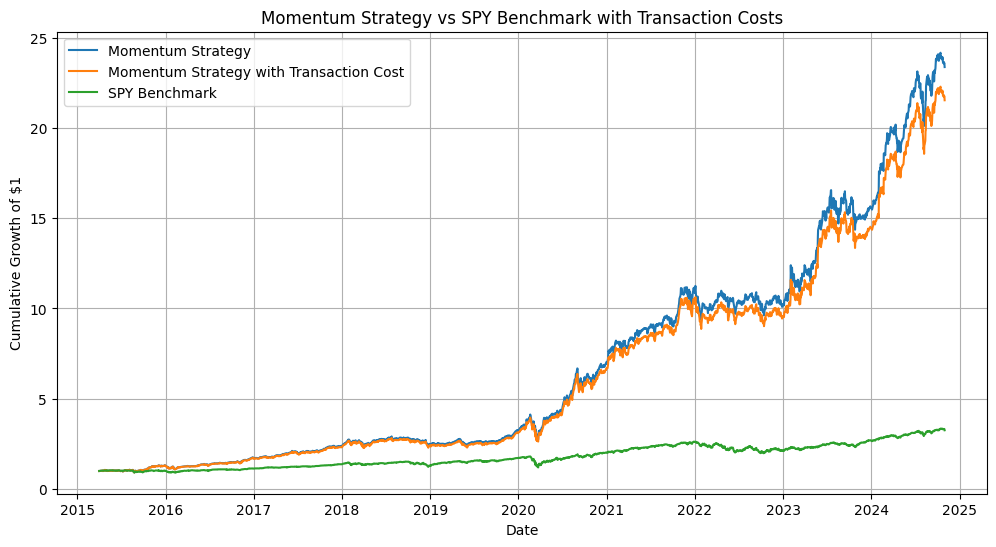

In [36]:
cumulative_strategy_tc = (1 + portfolio_returns_tc).cumprod()

cumulative_returns_tc = pd.DataFrame({
    "Momentum Strategy": cumulative_strategy,
    "Momentum Strategy with TC": cumulative_strategy_tc,
    "SPY Benchmark": cumulative_benchmark
})

plt.figure(figsize=(12, 6))

plt.plot(cumulative_returns_tc.index, cumulative_returns_tc["Momentum Strategy"], label="Momentum Strategy")
plt.plot(cumulative_returns_tc.index, cumulative_returns_tc["Momentum Strategy with TC"], label="Momentum Strategy with Transaction Cost")
plt.plot(cumulative_returns_tc.index, cumulative_returns_tc["SPY Benchmark"], label="SPY Benchmark")

plt.title("Momentum Strategy vs SPY Benchmark with Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

## Results Interpretation

The 60-day momentum strategy strongly outperformed the SPY benchmark during the 2015–2024 backtest period.

The strategy achieved a total return of 2237.57% before transaction costs and 2053.62% after applying a 0.10% transaction cost per monthly rebalance. In comparison, the SPY benchmark returned 225.32% over the same period.

The strategy also produced a higher Sharpe ratio than SPY:

- Momentum Strategy: 1.62
- Momentum Strategy with Transaction Costs: 1.57
- SPY Benchmark: 0.74

This suggests that the momentum strategy generated stronger risk-adjusted returns than the passive benchmark in this selected stock universe.

However, the results should not be interpreted as proof of a universally profitable strategy. The selected universe contains several large-cap technology stocks that performed extremely well during the backtest period, including companies such as NVDA, TSLA, META, AMZN, and MSFT. This likely contributed significantly to the strategy's strong performance.

## Limitations

This backtest has several important limitations:

1. Survivorship Bias  
   The stock universe is selected using companies that are known today. This means the backtest may exclude companies that performed poorly, were delisted, or became less relevant during the period.

2. Limited Universe Size  
   The strategy only uses 15 large-cap U.S. stocks. A broader universe would provide a more realistic test of the momentum effect.

3. Concentration Risk  
   The strategy selects only 5 stocks each month. This creates a concentrated portfolio and may increase exposure to specific sectors, especially technology stocks.

4. Simplified Transaction Costs  
   The transaction cost assumption is simplified. Real trading would also include bid-ask spreads, slippage, taxes, and liquidity constraints.

5. No Risk Management Rules  
   The strategy does not include stop-loss rules, volatility targeting, sector limits, or maximum position constraints.

6. Historical Performance Only  
   Strong historical performance does not guarantee future results. The strategy may perform differently in other market regimes.

## Next Steps

Possible improvements for this project include:

- Testing different momentum windows such as 20-day, 60-day, and 120-day momentum
- Comparing top 3, top 5, and top 10 stock selection rules
- Expanding the stock universe
- Adding sector constraints
- Adding volatility-adjusted position sizing
- Including more realistic transaction cost and slippage assumptions
- Comparing the strategy against other benchmarks
- Running the strategy on out-of-sample periods

In [37]:
print("Final Strategy Total Return:", formatted_metrics_tc.loc["Total Return", "Momentum Strategy with TC"])
print("Final Strategy Sharpe:", formatted_metrics_tc.loc["Sharpe Ratio", "Momentum Strategy with TC"])
print("Benchmark Total Return:", formatted_metrics_tc.loc["Total Return", "SPY Benchmark"])
print("Benchmark Sharpe:", formatted_metrics_tc.loc["Sharpe Ratio", "SPY Benchmark"])

Final Strategy Total Return: 2053.62%
Final Strategy Sharpe: 1.57
Benchmark Total Return: 225.32%
Benchmark Sharpe: 0.74


## Extended Test: Current S&P 500 Universe

In [39]:
import pandas as pd
import requests

sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(sp500_url, headers=headers)

sp500_table = pd.read_html(response.text)[0]

sp500_table.head()

/tmp/ipykernel_57/625722639.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(response.text)[0]


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [40]:
sp500_tickers = sp500_table["Symbol"].tolist()

# Yahoo Finance format fix
sp500_tickers = [ticker.replace(".", "-") for ticker in sp500_tickers]

print("Number of tickers:", len(sp500_tickers))
sp500_tickers[:20]

Number of tickers: 503


['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL']

In [41]:
sp500_benchmark = "SPY"

sp500_all_tickers = sp500_tickers + [sp500_benchmark]

sp500_price_data = yf.download(
    sp500_all_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column"
)

sp500_price_data.head()


2 Failed downloads:
['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735621200")')


Price      Adj Close           Close                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            \
Ticker             Q SNDK          A       AAPL       ABBV ABNB        ABT       ACGL        ACN       ADBE        ADI        ADM        ADP       ADSK        AEE        AEP       AES        AFL        AIG        AIZ        AJG       AKAM        ALB       ALGN        ALL       ALLE       AMAT       AMCR   AMD        AME        AMGN         AMP        AMT     AMZN      ANET        AON        AOS        APA         APD        APH        APO APP       APTV        ARE       ARES        ATO         AVB      AVGO        AVY        AWK       AXON        AXP         AZO          BA        BAC       BALL        BAX        BBY        BDX        BEN       BF-B         BG        BIIB         BK       BKNG        BKR  BLDR         BLK        BMY         BR       BRK-B        BRO    BSX         BX        BXP          C        CAG        CAH CARR       CASY        CAT         CB       CBOE       CBRE        CCI        CCL       CDNS        CDW CEG         CF        CFG        CHD       CHRW   
Date                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
2015-01-02       NaN  NaN  36.970364  24.192602  41.411907  NaN  36.009209  18.539352  73.628242  72.339996  44.216057  37.381657  65.025337  59.529999  32.671497  40.750816  8.907229  23.427658  42.835594  54.260956  38.173462  63.250000  51.245464  56.200001  54.941746  48.664227  21.737465  35.271282  2.67  48.793655  115.635269  103.935005  75.751213  15.4260  3.917500  84.683769  23.225428  48.152580  102.235634  12.062371  13.929945 NaN  57.221512  60.154713  10.361079  42.634518  113.942780  7.544513  41.878590  43.110893  26.510000  79.040215  616.789978  113.657234  14.123800  30.446436  33.156273  25.567223  90.150467  33.256363  28.892838  66.203835  342.010010  30.539131  44.844646  29.743002  6.75  269.715454  40.884258  37.381252  149.169998  14.596338  13.22  19.220877  84.040413  40.013985  18.286537  59.366871  NaN  81.864296  69.027138  93.015976  54.799614  34.669998  49.799221  38.736855  18.830000  30.604553 NaN  40.702442  16.597919  34.031300  56.744061   
2015-01-05       NaN  Na

In [42]:
sp500_price_data.columns

MultiIndex([('Adj Close',    'Q'),
            ('Adj Close', 'SNDK'),
            (    'Close',    'A'),
            (    'Close', 'AAPL'),
            (    'Close', 'ABBV'),
            (    'Close', 'ABNB'),
            (    'Close',  'ABT'),
            (    'Close', 'ACGL'),
            (    'Close',  'ACN'),
            (    'Close', 'ADBE'),
            ...
            (   'Volume',   'WY'),
            (   'Volume', 'WYNN'),
            (   'Volume',  'XEL'),
            (   'Volume',  'XOM'),
            (   'Volume',  'XYL'),
            (   'Volume',  'XYZ'),
            (   'Volume',  'YUM'),
            (   'Volume',  'ZBH'),
            (   'Volume', 'ZBRA'),
            (   'Volume',  'ZTS')],
           names=['Price', 'Ticker'], length=2522)

In [43]:
sp500_prices = sp500_price_data["Close"].copy()

sp500_prices.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,AON,AOS,APA,APD,APH,APO,APP,APTV,ARE,ARES,ATO,AVB,AVGO,AVY,AWK,AXON,AXP,AZO,BA,BAC,BALL,BAX,BBY,BDX,BEN,BF-B,BG,BIIB,BK,BKNG,BKR,BLDR,BLK,BMY,BR,BRK-B,BRO,BSX,BX,BXP,C,CAG,CAH,CARR,CASY,CAT,CB,CBOE,CBRE,CCI,CCL,CDNS,CDW,CEG,CF,CFG,CHD,CHRW,CHTR,CI,CIEN,CINF,CL,CLX,CMCSA,CME,CMG,CMI,CMS,CNC,CNP,COF,COHR,COIN,COO,COP,COR,COST,CPAY,CPB,CPRT,CPT,CRH,CRL,CRM,CRWD,CSCO,CSGP,CSX,CTAS,CTSH,CTVA,CVNA,CVS,CVX,D,DAL,DASH,DD,DDOG,DE,DECK,DELL,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOC,DOV,DOW,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EG,EIX,EL,ELV,EME,EMR,EOG,EPAM,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FISV,FITB,FIX,FOX,FOXA,FRT,FSLR,FTNT,FTV,GD,GDDY,GE,GEHC,GEN,GEV,GILD,GIS,GL,GLW,GM,GNRC,GOOG,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HCA,HD,HIG,HII,HLT,HON,HOOD,HPE,HPQ,HRL,HSIC,HST,HSY,HUBB,HUM,HWM,IBKR,IBM,ICE,IDXX,IEX,IFF,INCY,INTC,INTU,INVH,IP,IQV,IR,IRM,ISRG,IT,ITW,IVZ,J,JBHT,JBL,JCI,JKHY,JNJ,JPM,KDP,KEY,KEYS,KHC,KIM,KKR,KLAC,KMB,KMI,KO,KR,KVUE,L,LDOS,LEN,LH,LHX,LII,LIN,LITE,LLY,LMT,LNT,LOW,LRCX,LULU,LUV,LVS,LYB,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,META,MGM,MKC,MLM,MMM,MNST,MO,MOS,MPC,MPWR,MRK,MRNA,MRSH,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NCLH,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NOW,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,NWS,NWSA,NXPI,O,ODFL,OKE,OMC,ON,ORCL,ORLY,OTIS,OXY,PANW,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PLTR,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PSKY,PSX,PTC,PWR,PYPL,Q,QCOM,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,RTX,RVTY,SATS,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNDK,SNPS,SO,SOLV,SPG,SPGI,SPY,SRE,STE,STLD,STT,STX,STZ,SW,SWK,SWKS,SYF,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TFC,TGT,TJX,TKO,TMO,TMUS,TPL,TPR,TRGP,TRMB,TROW,TRV,TSCO,TSLA,TSN,TT,TTD,TTWO,TXN,TXT,TYL,UAL,UBER,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VEEV,VICI,VLO,VLTO,VMC,VRSK,VRSN,VRT,VRTX,VST,VTR,VTRS,VZ,WAB,WAT,WBD,WDAY,WDC,WEC,WELL,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,36.970364,24.192602,41.411907,NaN,36.009209,18.539352,73.628242,72.339996,44.216057,37.381657,65.025337,59.529999,32.671497,40.750816,8.907229,23.427658,42.835594,54.260956,38.173462,63.250000,51.245464,56.200001,54.941746,48.664227,21.737465,35.271282,2.67,48.793655,115.635269,103.935005,75.751213,15.4260,3.917500,84.683769,23.225428,48.152580,102.235634,12.062371,13.929945,NaN,57.221512,60.154713,10.361079,42.634518,113.942780,7.544513,41.878590,43.110893,26.510000,79.040215,616.789978,113.657234,14.123800,30.446436,33.156273,25.567223,90.150467,33.256363,28.892838,66.203835,342.010010,30.539131,44.844646,29.743002,6.75,269.715454,40.884258,37.381252,149.169998,14.596338,13.22,19.220877,84.040413,40.013985,18.286537,59.366871,NaN,81.864296,69.027138,93.015976,54.799614,34.669998,49.799221,38.736855,18.830000,30.604553,NaN,40.702442,16.597919,34.031300,56.744061,166.429993,93.412621,19.540001,37.656124,52.743927,74.329407,20.379925,56.471008,13.5680,108.209763,24.886196,26.110001,16.048435,67.311951,13.54,NaN,40.064968,47.563759,66.241478,113.815147,150.259995,30.199589,4.57250,48.566715,17.778086,63.880001,58.382847,NaN,19.603914,18.013000,10.033468,17.486296,46.458458,NaN,NaN,68.434967,69.529404,47.991894,42.948307,NaN,20.883577,NaN,72.451759,14.956667,NaN,61.007381,54.742157,21.984150,34.932934,85.365929,44.181145,70.349998,22.173729,4

In [44]:
missing_summary = sp500_prices.isna().sum().sort_values(ascending=False)

missing_summary.head(20)

Ticker
SNDK    2515
Q       2515
GEV     2323
SOLV    2322
VLTO    2203
KVUE    2098
GEHC    2003
CEG     1774
HOOD    1654
APP     1581
COIN    1580
EXE     1537
ABNB    1496
DASH    1495
PLTR    1446
OTIS    1311
CARR    1311
DDOG    1186
CRWD    1117
CTVA    1105
dtype: int64

In [45]:
min_data_ratio = 0.80

valid_tickers = sp500_prices.columns[
    sp500_prices.notna().mean() >= min_data_ratio
].tolist()

print("Original number of tickers:", len(sp500_prices.columns))
print("Valid number of tickers:", len(valid_tickers))

sp500_prices_clean = sp500_prices[valid_tickers].ffill().dropna()

sp500_prices_clean.shape

Original number of tickers: 504
Valid number of tickers: 474


(2053, 474)

In [46]:
if sp500_benchmark not in sp500_prices_clean.columns:
    print("SPY was removed during cleaning. Check missing data threshold.")
else:
    sp500_stock_tickers = [ticker for ticker in sp500_prices_clean.columns if ticker != sp500_benchmark]

    sp500_stock_prices = sp500_prices_clean[sp500_stock_tickers]
    sp500_benchmark_prices = sp500_prices_clean[sp500_benchmark]

    sp500_stock_returns = sp500_stock_prices.pct_change().dropna()
    sp500_benchmark_returns = sp500_benchmark_prices.pct_change().dropna()

    print("Stock universe:", len(sp500_stock_tickers))
    print("Stock prices shape:", sp500_stock_prices.shape)
    print("Stock returns shape:", sp500_stock_returns.shape)
    print("Benchmark returns shape:", sp500_benchmark_returns.shape)

Stock universe: 473
Stock prices shape: (2053, 473)
Stock returns shape: (2052, 473)
Benchmark returns shape: (2052,)


In [47]:
sp500_prices_clean.shape

(2053, 474)

In [49]:
print("Start date:", sp500_prices_clean.index.min())
print("End date:", sp500_prices_clean.index.max())
print("Shape:", sp500_prices_clean.shape)

Start date: 2016-11-01 00:00:00
End date: 2024-12-30 00:00:00
Shape: (2053, 474)


In [50]:
sp500_benchmark = "SPY"

sp500_stock_tickers = [
    ticker for ticker in sp500_prices_clean.columns 
    if ticker != sp500_benchmark
]

sp500_stock_prices = sp500_prices_clean[sp500_stock_tickers]
sp500_benchmark_prices = sp500_prices_clean[sp500_benchmark]

sp500_stock_returns = sp500_stock_prices.pct_change().dropna()
sp500_benchmark_returns = sp500_benchmark_prices.pct_change().dropna()

print("Stock universe:", len(sp500_stock_tickers))
print("Stock prices shape:", sp500_stock_prices.shape)
print("Stock returns shape:", sp500_stock_returns.shape)
print("Benchmark returns shape:", sp500_benchmark_returns.shape)

Stock universe: 473
Stock prices shape: (2053, 473)
Stock returns shape: (2052, 473)
Benchmark returns shape: (2052,)


In [51]:
sp500_momentum_60d = sp500_stock_prices.pct_change(60)

sp500_monthly_rebalance_dates = sp500_stock_prices.resample("ME").last().index

sp500_top_n = 20

sp500_monthly_momentum = sp500_momentum_60d.reindex(sp500_monthly_rebalance_dates)

sp500_selected_stocks = {}

for date in sp500_monthly_momentum.index:
    signal = sp500_monthly_momentum.loc[date].dropna()
    
    if len(signal) >= sp500_top_n:
        sp500_selected_stocks[date] = signal.sort_values(ascending=False).head(sp500_top_n).index.tolist()

len(sp500_selected_stocks)

67

In [52]:
sp500_selected_df = pd.DataFrame.from_dict(
    sp500_selected_stocks,
    orient="index"
)

sp500_selected_df.columns = [f"Stock_{i+1}" for i in range(sp500_selected_df.shape[1])]

sp500_selected_df.head(10)

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5,Stock_6,Stock_7,Stock_8,Stock_9,Stock_10,Stock_11,Stock_12,Stock_13,Stock_14,Stock_15,Stock_16,Stock_17,Stock_18,Stock_19,Stock_20
2017-01-31,URI,NRG,NVDA,FCX,AMD,CSX,WDC,MU,CF,STX,CFG,INCY,VST,BAC,RF,COHR,MTB,TSLA,SCHW,LUV
2017-02-28,AMD,TTD,HWM,NRG,CSX,VST,XYZ,TSLA,INCY,PODD,ON,NCLH,URI,ARES,ANET,PM,AAPL,AVGO,LUV,LLY
2017-03-31,NRG,VRTX,LITE,DXCM,TTD,HWM,IDXX,SWKS,ANET,INCY,MU,WYNN,CSX,AMD,GEN,FTNT,PM,NVR,ADBE,PHM
2017-05-31,NVDA,VEEV,ALGN,XYZ,BBY,VRTX,TSLA,ADSK,LRCX,TTWO,EA,TTD,WYNN,DECK,EW,CSGP,AMAT,MAR,ISRG,ANET
2017-06-30,FSLR,NVDA,XYZ,TTD,ALGN,REGN,CSGP,EW,TTWO,PYPL,PANW,NOW,MTD,PKG,IEX,ISRG,TSLA,PODD,COO,TPR
2017-07-31,NRG,NVDA,FSLR,AMD,TTD,BA,LITE,XYZ,VRTX,COHR,FCX,TTWO,EA,PODD,CHTR,NVR,ADP,PYPL,LULU,COO
2017-08-31,NRG,TPL,PODD,GILD,VRTX,BA,RL,FSLR,FCX,BIIB,TTWO,IRM,ALGN,TROW,TDY,NCLH,EQT,XYL,CRL,BMY
2017-10-31,MU,XYZ,ALGN,GNRC,LRCX,IBKR,FIX,ON,AMAT,DELL,ABBV,TKO,TER,ODFL,INTC,GM,PTC,TTWO,NVR,PYPL
2017-11-30,XYZ,ALGN,NTAP,DHI,IBKR,GWW,ANET,PHM,CPRT,QCOM,URI,MU,FSLR,COHR,TKO,DE,CPAY,ODFL,LII,ROST
2018-01-31,STX,ANET,WBD,KR,KDP,NTAP,LOW,FCX,COR,GWW,BA,NFLX,TKO,AMZN,HCA,TPL,PODD,DVA,XYZ,LULU


In [53]:
sp500_portfolio_returns = pd.Series(index=sp500_stock_returns.index, dtype=float)

sp500_rebalance_dates = list(sp500_selected_stocks.keys())

for i in range(len(sp500_rebalance_dates) - 1):
    current_date = sp500_rebalance_dates[i]
    next_date = sp500_rebalance_dates[i + 1]
    
    selected = sp500_selected_stocks[current_date]
    
    period_returns = sp500_stock_returns.loc[
        (sp500_stock_returns.index > current_date) &
        (sp500_stock_returns.index <= next_date),
        selected
    ]
    
    sp500_portfolio_returns.loc[period_returns.index] = period_returns.mean(axis=1)

sp500_portfolio_returns = sp500_portfolio_returns.dropna()

sp500_aligned_benchmark_returns = sp500_benchmark_returns.loc[sp500_portfolio_returns.index]

print("Strategy returns shape:", sp500_portfolio_returns.shape)
print("Benchmark returns shape:", sp500_aligned_benchmark_returns.shape)

sp500_portfolio_returns.head()

Strategy returns shape: (1951,)
Benchmark returns shape: (1951,)


Date
2017-02-01    0.017539
2017-02-02   -0.005758
2017-02-03    0.007201
2017-02-06    0.004568
2017-02-07   -0.004005
dtype: float64

In [54]:
sp500_cumulative_strategy = (1 + sp500_portfolio_returns).cumprod()
sp500_cumulative_benchmark = (1 + sp500_aligned_benchmark_returns).cumprod()

sp500_cumulative_returns = pd.DataFrame({
    "S&P 500 Momentum Strategy": sp500_cumulative_strategy,
    "SPY Benchmark": sp500_cumulative_benchmark
})

sp500_cumulative_returns.tail()

,S&P 500 Momentum Strategy,SPY Benchmark
Date,,
2024-10-25,5.281044,2.895700
2024-10-28,5.331779,2.904652
2024-10-29,5.236963,2.909353
2024-10-30,5.211189,2.900551
2024-10-31,5.189072,2.843692


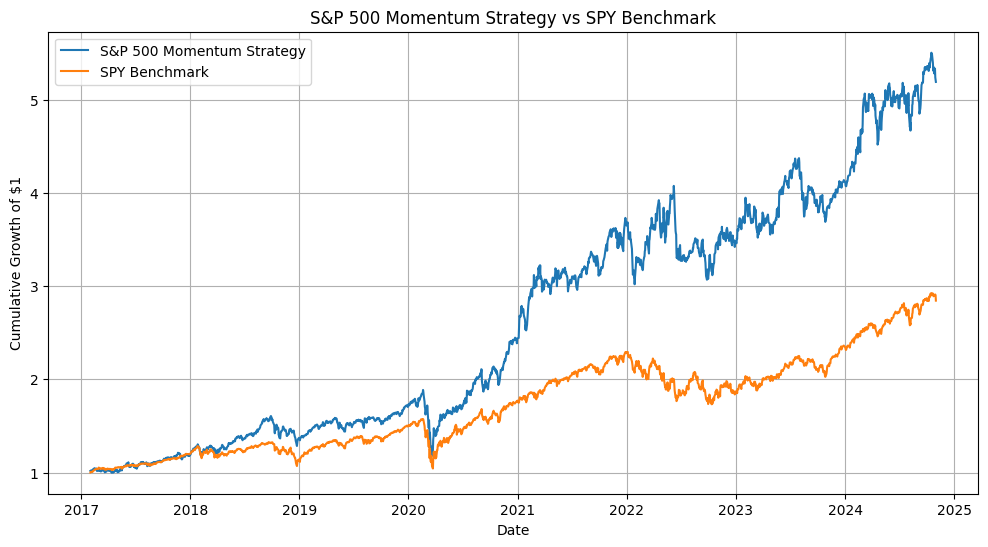

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(
    sp500_cumulative_returns.index,
    sp500_cumulative_returns["S&P 500 Momentum Strategy"],
    label="S&P 500 Momentum Strategy"
)

plt.plot(
    sp500_cumulative_returns.index,
    sp500_cumulative_returns["SPY Benchmark"],
    label="SPY Benchmark"
)

plt.title("S&P 500 Momentum Strategy vs SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
sp500_strategy_metrics = calculate_performance_metrics(sp500_portfolio_returns)
sp500_benchmark_metrics = calculate_performance_metrics(sp500_aligned_benchmark_returns)

sp500_metrics_df = pd.DataFrame({
    "S&P 500 Momentum Strategy": sp500_strategy_metrics,
    "SPY Benchmark": sp500_benchmark_metrics
})

sp500_formatted_metrics = sp500_metrics_df.copy().astype(object)

for row in percentage_rows:
    sp500_formatted_metrics.loc[row] = sp500_formatted_metrics.loc[row].apply(lambda x: f"{x:.2%}")

sp500_formatted_metrics.loc["Sharpe Ratio"] = sp500_formatted_metrics.loc["Sharpe Ratio"].apply(lambda x: f"{x:.2f}")

sp500_formatted_metrics

,S&P 500 Momentum Strategy,SPY Benchmark
Total Return,418.91%,184.37%
Annualized Return,23.70%,14.45%
Annualized Volatility,24.04%,18.53%
Sharpe Ratio,0.99,0.78
Max Drawdown,-37.83%,-33.72%
Win Rate,56.84%,55.41%


## Extended Test: Current S&P 500 Universe

To make the backtest more realistic, I extended the strategy from a small 15-stock sample to the current S&P 500 universe.

After filtering for sufficient historical data, the final universe included 474 tickers. The test period started on 2016-11-01 and ended on 2024-12-30.

In this version, the strategy selected the top 20 stocks by 60-day momentum at each monthly rebalance and held them equally weighted until the next rebalance.

### Results

| Metric | S&P 500 Momentum Strategy | SPY Benchmark |
|---|---:|---:|
| Total Return | 418.91% | 184.37% |
| Annualized Return | 23.70% | 14.45% |
| Annualized Volatility | 24.04% | 18.53% |
| Sharpe Ratio | 0.99 | 0.78 |
| Max Drawdown | -37.83% | -33.72% |
| Win Rate | 56.84% | 55.41% |

The S&P 500 momentum strategy outperformed SPY in terms of total return, annualized return, Sharpe ratio, and win rate.

However, the strategy also had higher volatility and a larger maximum drawdown. This means the strategy generated stronger returns, but with higher risk.

Compared with the initial 15-stock test, the results are less extreme and more realistic. This suggests that the earlier result was likely amplified by the small universe and strong performance of large-cap technology stocks.

This extended test still uses the current S&P 500 universe, so it may contain survivorship bias. A more rigorous version would use historical S&P 500 constituents and update the investable universe through time.